In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import salem

In [2]:
from oggm import cfg, utils, workflow, tasks, graphics
cfg.initialize(logging_level='WARNING')

2025-01-08 11:25:30: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-08 11:25:30: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-08 11:25:30: oggm.cfg: Multiprocessing: using all available processors (N=16)


In [3]:
# Local working directory (where OGGM will write its output)
# WORKING_DIR = utils.gettempdir('OGGM_distr4')
cfg.PATHS['working_dir'] = '/home/usman/Music/GeeMap /OGGM/data'

In [4]:
pwd


'/home/usman/Music/GeeMap /OGGM'

In [5]:
rgi_ids = ['RGI60-14.02192']  # Fieschergletscher

In [6]:
# The RGI version to use
# Size of the map around the glacier.
prepro_border = 80
# Degree of processing level. This is OGGM specific and for the shop 1 is the one you want
from_prepro_level = 3
# URL of the preprocessed gdirs
# we use elevation bands flowlines here
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5'
gdirs = workflow.init_glacier_directories(rgi_ids,
                                          from_prepro_level=from_prepro_level,
                                          prepro_base_url=base_url,
                                          prepro_border=prepro_border)

2025-01-08 11:25:32: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-01-08 11:25:32: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [7]:
gdir = gdirs[0]

In [12]:
graphics.plot_googlemap(gdir, figsize=(8, 7), key='your-google-api-key')


ValueError: You need to provide a Google API key or set the STATIC_MAP_API_KEY environment variable.

In [13]:
fpath = gdir.get_filepath('gridded_data')
fpath

'/home/usman/Music/GeeMap /OGGM/data/per_glacier/RGI60-14/RGI60-14.02/RGI60-14.02192/gridded_data.nc'

In [14]:
with xr.open_dataset(fpath) as ds:
    ds = ds.load()

In [15]:
ds

<xarray.Dataset> Size: 884kB
Dimensions:          (x: 318, y: 252)
Coordinates:
  * x                (x) float32 1kB -2.418e+04 -2.404e+04 ... 1.925e+04
  * y                (y) float32 1kB 4.07e+06 4.069e+06 ... 4.035e+06 4.035e+06
Data variables:
    topo             (y, x) float32 321kB 4.213e+03 4.108e+03 ... 4.325e+03
    topo_smoothed    (y, x) float32 321kB 4.176e+03 4.134e+03 ... 4.188e+03
    topo_valid_mask  (y, x) int8 80kB 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    glacier_mask     (y, x) int8 80kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    glacier_ext      (y, x) int8 80kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
Attributes:
    author:         OGGM
    author_info:    Open Global Glacier Model
    pyproj_srs:     +proj=tmerc +lat_0=0 +lon_0=74.2238 +k=0.9996 +x_0=0 +y_0...
    max_h_dem:      7110.0
    min_h_dem:      2411.0
    max_h_glacier:  7013.0
    min_h_glacier:  2886.0

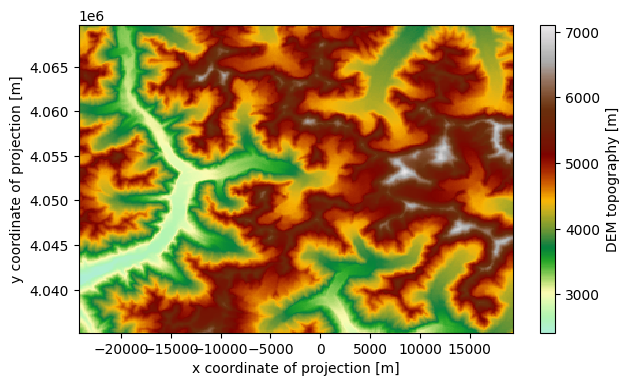

In [16]:
cmap=salem.get_cmap('topo')
ds.topo.plot(figsize=(7, 4), cmap=cmap);

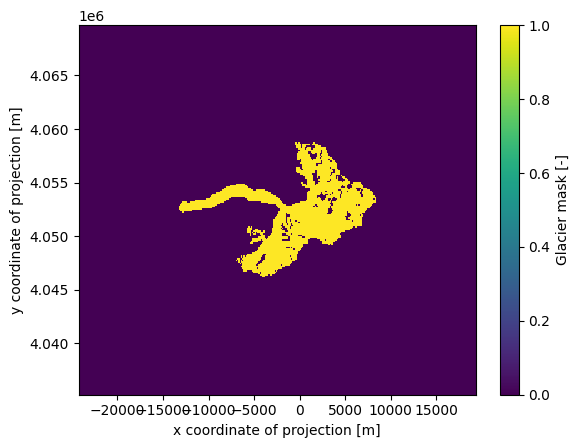

In [17]:
ds.glacier_mask.plot();

In [6]:
from oggm.shop import bedtopo
from oggm import workflow


In [7]:
workflow.execute_entity_task(bedtopo.add_consensus_thickness, gdirs);

NameError: name 'gdirs' is not defined

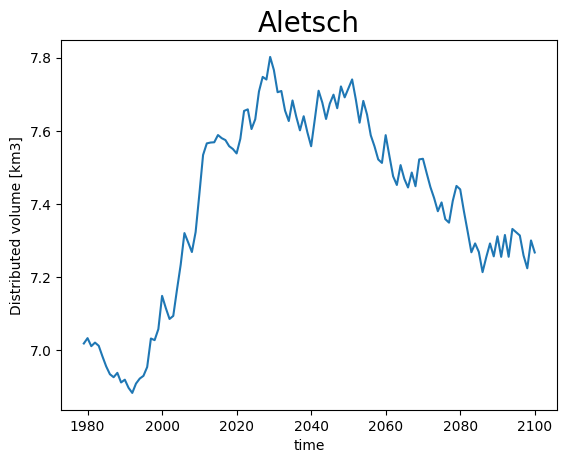

In [15]:
def plot_volume(ds, gdir, title):
    vol = ds.simulated_thickness.sum(dim=['x', 'y']) * gdir.grid.dx**2 * 1e-9
    vol.plot(label='Distributed volume'); plt.ylabel('Distributed volume [km3]');
    plt.title(title, fontsize=20); plt.show();


plot_volume(ds[0], gdirs[0], 'Aletsch')
# plot_volume(ds[1], gdirs[1], 'Fieschergletscher')

In [16]:
for i, (ds_single, gdir) in enumerate(zip(ds, gdirs)):
    ds[i] = ds_single.sel(time=slice(gdir.rgi_date, None))

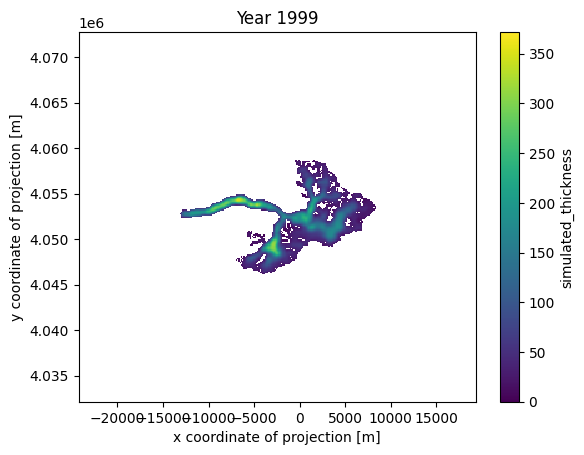

In [17]:
from matplotlib import animation
from IPython.display import HTML, display

# Get a handle on the figure and the axes
fig, ax = plt.subplots()

thk = ds[0]['simulated_thickness']  # Aletsch
# thk = ds[1]['simulated_thickness']  # Fieschergletscher

# Plot the initial frame. 
cax = thk.isel(time=0).plot(ax=ax,
    add_colorbar=True,
    cmap='viridis',
    vmin=0, vmax=thk.max(),
    cbar_kwargs={
        'extend':'neither'
    }
)
ax.axis('equal')

def animate(frame):
    ax.set_title(f'Year {int(thk.time[frame])}')
    cax.set_array(thk.values[frame, :].flatten())

ani_glacier = animation.FuncAnimation(fig, animate, frames=len(thk.time), interval=100);

In [18]:
HTML(ani_glacier.to_jshtml())